# Analisi del dataset
## 1. Caricamento dataset prova
Carico il dataset prova a cui mancano i valori e altri due dataset completi generati randomicamente

In [4]:
import pandas as pd
df = pd.read_excel('Esempio_Appello.xls')
print(df.head())

            GRUPPO_GIUD_COD   VOTO_1         SUBSET   19  \
0                    CDS_ID  10643.0            NaN  NaN   
1                     AD_ID  20089.0            NaN  NaN   
2                    APP_ID     23.0            NaN  NaN   
3                 FIRST_ROW     21.0  FIRST_DYN_COL    8   
4  Attività Didattica [COD]      NaN            NaN  NaN   

          FLD_LIV_LINGUE Unnamed: 5 Unnamed: 6  Unnamed: 7 Unnamed: 8  \
0                    NaN        NaN        NaN         NaN        NaN   
1                    NaN        NaN        NaN         NaN        NaN   
2                    NaN        NaN        NaN         NaN        NaN   
3                    NaN        NaN        NaN         NaN        NaN   
4  Corso di Studio [COD]        NaN        NaN         NaN        NaN   

  Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12 Unnamed: 13 Unnamed: 14  \
0        NaN         NaN         NaN         NaN         NaN         NaN   
1        NaN         NaN         NaN         NaN

### Carico tutti i dataset
Dopo aver effettuato la prova con il primo ricarico tutti i dati che ho nella cartella e do il nome ad ogni dataset identificativo.

In [ ]:
import os
import pandas as pd
cartella = "./"   # oppure es: "./appelli/"
files_xls = [f for f in os.listdir(cartella) if f.endswith(".xls")]
print(f"Dataset trovati: {len(files_xls)}")
print(files_xls)

#carico i dati in una lista di dataset
datasets = []
for file in files_xls:
    df = pd.read_excel(os.path.join(cartella, file))
    datasets.append({
        "nome_file": file,
        "raw": df
    })
len(datasets)

Dataset trovati: 3
['Esempio_Appello copy 2.xls', 'Esempio_Appello copy.xls', 'Esempio_Appello.xls']


3

## 2. Separare intestazione dai valori
Ad ogni descrizione (intestazione) corrispondono i relativi dati.
Separiamo le due parti affinche se decido di analizzare i dati di Appello1 potrò richiamare i dati relativi all'appello corretto.

In [33]:
raw_df = pd.read_excel("Esempio_Appello.xls", header=None)
start_students = raw_df[raw_df[0] == "Elenco Studenti Iscritti all'Appello"].index[0]
print(start_students)

19


In [34]:
intestazione_raw = raw_df.iloc[:start_students]

# Trasformiamo l'intestazione in dizionario
intestazione = {}

for _, row in intestazione_raw.iterrows():
    chiave = row[0]
    valore = row[3]  # nei tuoi file il valore è quasi sempre qui
    if pd.notna(chiave):
        intestazione[str(chiave).strip()] = valore

# Visualizziamo l'intestazione
print("INTESTAZIONE APPPELLO:")
for k, v in intestazione.items():
    print(f"- {k}: {v}")

INTESTAZIONE APPPELLO:
- GRUPPO_GIUD_COD: 19
- CDS_ID: nan
- AD_ID: nan
- APP_ID: nan
- FIRST_ROW: 8
- Attività Didattica [COD]: nan
- FONDAMENTI DI SCIENZA DEI DATI E LABORATORIO [MA0682]: nan
- Sessioni: SESSIONE UNICA A.A. 2024/2025 [01/10/2024 - 30/04/2026]
- Descrizione Appello: Esame orale
- Tipo di Prova: Orale
- Prenotazione (dal-al): 21/08/2025 - 21/09/2025
- Date Appello: 23/09/2025 - 09:00:00 - Nessun partizionamento - Esame orale - Rizzi - Aula A023 (ex aula 47)
- Totale Studenti iscritti: 19
- Tipo Esito: Voto in trentesimi (31 = 30L, ASS = Assente, 0 = Insufficiente, RIT = Ritirato)
- Tipo Svolgimento Esame: P = Esame in Presenza, D = Esame a Distanza


In [15]:
header_row = start_students + 1

studenti = raw_df.iloc[header_row + 1:]
studenti.columns = raw_df.iloc[header_row]

# Pulizia
studenti = studenti.dropna(how="all")
studenti = studenti.reset_index(drop=True)

print("\nPRIME RIGHE STUDENTI:")
studenti.head(10)


PRIME RIGHE STUDENTI:


20,#,NaN,Matricola,Cognome,Nome,Anno Freq.,CFU,NaN,Esito,Svolgimento Esame,Domande d'esame,Data superamento,Nota per lo studente,Presa Visione,CDS COD.,AD COD.,Misure Compensative,Email
0,1,NaN,NaN,NaN,NaN,2024/2025,6,224183.0,0,P,NaN,NaN,NaN,A,819,MA0682,NaN,NaN
1,2,NaN,NaN,NaN,NaN,2024/2025,6,224375.0,18,P,NaN,NaN,NaN,N,819,MA0682,NaN,NaN
2,3,NaN,NaN,NaN,NaN,2023/2024,6,212383.0,25,P,NaN,NaN,NaN,N,819,MA0682,NaN,NaN
3,4,NaN,NaN,NaN,NaN,2024/2025,6,223243.0,28,P,NaN,NaN,NaN,A,819,MA0682,NaN,NaN
4,5,NaN,NaN,NaN,NaN,2024/2025,6,224981.0,30,P,NaN,NaN,NaN,N,819,MA0682,NaN,NaN
5,6,NaN,NaN,NaN,NaN,2024/2025,6,225616.0,31,P,NaN,NaN,NaN,A,819,MA0682,NaN,NaN
6,7,NaN,NaN,NaN,NaN,2024/2025,6,226295.0,ASS,P,NaN,NaN,NaN,A,819,MA0682,NaN,NaN
7,8,NaN,NaN,NaN,NaN,2023/2024,6,215477.0,RIT,P,NaN,NaN,NaN,A,819,MA0682,NaN,NaN
8,9,NaN,NaN,NaN,NaN,2024/2025,6,223989.0,0,P,NaN,NaN,NaN,N,819,MA0682,NaN,NaN
9,10,NaN,163002,BLANDINO,ALICE,2022/2023,6,204444.0,25,P,NaN,NaN,NaN,A,819,MA0682,NaN,blandino.alice@spes.uniud.it


In [43]:
def parse_appello(df):
    # df è già un DataFrame letto con pandas
    raw = df.copy()

    # resettiamo le colonne a 0,1,2,3...
    raw.columns = range(raw.shape[1])

    # troviamo inizio elenco studenti
    start = raw[raw[0] == "Elenco Studenti Iscritti all'Appello"].index[0]

    # -------- METADATI --------
    meta_raw = raw.iloc[:start]
    meta = {}

    for _, row in meta_raw.iterrows():
        if pd.notna(row[0]):
            meta[str(row[0]).strip()] = row[3]

    # -------- STUDENTI --------
    header_row = start + 1
    studenti = raw.iloc[header_row + 1:]
    studenti.columns = raw.iloc[header_row]
    studenti = studenti.dropna(how="all").reset_index(drop=True)

    return meta, studenti


In [44]:
appelli = []

for d in datasets:
    meta, studenti = parse_appello(d["raw"])
    appelli.append({
        "nome_file": d["nome_file"],
        "meta": meta,
        "studenti": studenti
    })


In [45]:
print("APPPELLI CARICATI:\n")

for i, app in enumerate(appelli, start=1):
    data = app["meta"].get("Date Appello", "N/D")
    print(f"{i}. {app['nome_file']} → Data appello: {data}")


APPPELLI CARICATI:

1. Esempio_Appello copy 2.xls → Data appello: 23/09/2025 - 09:00:00 - Nessun partizionamento - Esame orale - Rizzi - Aula A023 (ex aula 47)
2. Esempio_Appello copy.xls → Data appello: 23/09/2025 - 09:00:00 - Nessun partizionamento - Esame orale - Rizzi - Aula A023 (ex aula 47)
3. Esempio_Appello.xls → Data appello: 23/09/2025 - 09:00:00 - Nessun partizionamento - Esame orale - Rizzi - Aula A023 (ex aula 47)


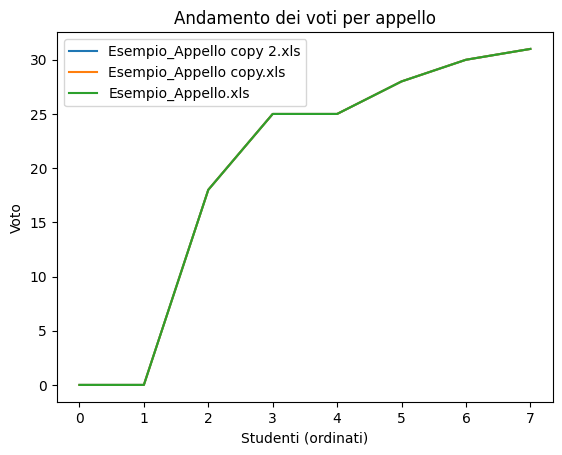

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for app in appelli:
    studenti = app["studenti"]

    voti = pd.to_numeric(studenti["Esito"], errors="coerce")
    voti = voti.dropna()

    plt.plot(sorted(voti), label=app["nome_file"])

plt.title("Andamento dei voti per appello")
plt.xlabel("Studenti (ordinati)")
plt.ylabel("Voto")
plt.legend()
plt.show()



In [49]:
medie = []

for app in appelli:
    voti = pd.to_numeric(app["studenti"]["Esito"], errors="coerce")
    media = voti.mean()

    data = app["meta"].get("Date Appello", app["nome_file"])

    medie.append({
        "appello": data,
        "media_voto": media
    })

df_medie = pd.DataFrame(medie)
df_medie


,appello,media_voto
0,23/09/2025 - 09:00:00 - Nessun partizionamento...,19.625
1,23/09/2025 - 09:00:00 - Nessun partizionamento...,19.625
2,23/09/2025 - 09:00:00 - Nessun partizionamento...,19.625


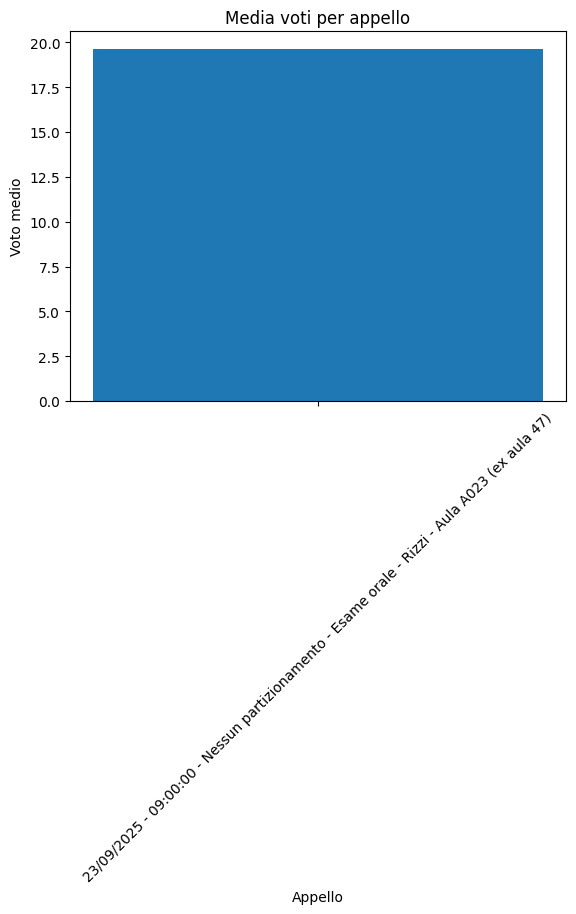

In [50]:
plt.figure()
plt.bar(df_medie["appello"], df_medie["media_voto"])
plt.title("Media voti per appello")
plt.xlabel("Appello")
plt.ylabel("Voto medio")
plt.xticks(rotation=45)
plt.show()


## 3. Generazione grafici
Proviamo con varie tipologie di grafici e relazioni per capire quali di questi ha più senso esaminare

In [28]:
appelli = []
appelli.append({
    "meta": intestazione,
    "studenti": studenti
})
print(f"Numero di dataset caricati: {len(appelli)}")



Numero di dataset caricati: 1


In [27]:
riassunto = []

for appello in appelli:
    meta = appello["meta"]
    studenti_df = appello["studenti"]

    # Data appello (prendiamo la prima data)
    data_esame = meta["Date Appello"].split(" - ")[0]

    # Partecipazione = studenti con esito valorizzato
    partecipazione = studenti_df["Esito"].notna().sum()

    riassunto.append({
        "data_esame": pd.to_datetime(data_esame, dayfirst=True),
        "partecipazione": partecipazione
    })


In [25]:
df_partecipazione = pd.DataFrame(riassunto)
df_partecipazione


,data_esame,partecipazione
0,2025-09-23,10


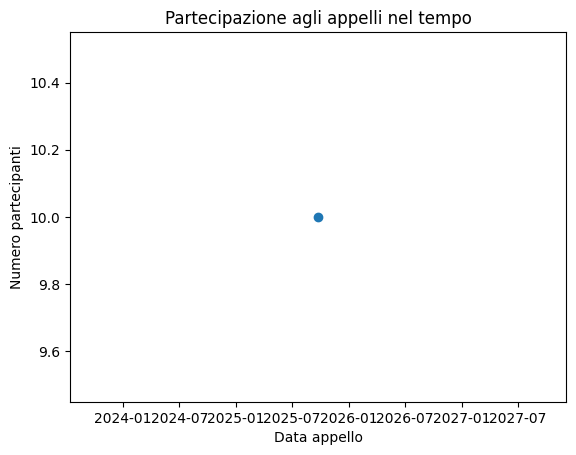

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_partecipazione["data_esame"],
         df_partecipazione["partecipazione"],
         marker='o')

plt.title("Partecipazione agli appelli nel tempo")
plt.xlabel("Data appello")
plt.ylabel("Numero partecipanti")
plt.show()


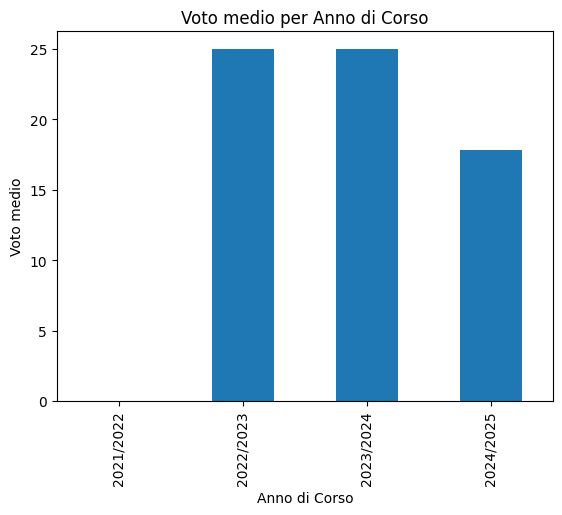

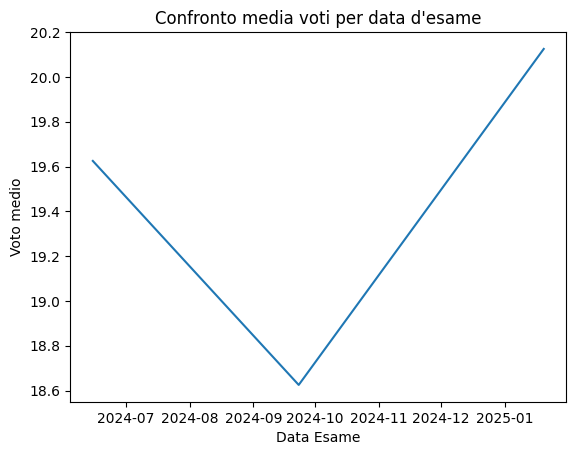

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Carichiamo e parsifichiamo il dataset come fatto prima
raw_df = pd.read_excel("Esempio_Appello.xls", header=None)
start_students = raw_df[raw_df[0] == "Elenco Studenti Iscritti all'Appello"].index[0]

# Estrazione studenti
header_row = start_students + 1
studenti = raw_df.iloc[header_row + 1:]
studenti.columns = raw_df.iloc[header_row]
studenti = studenti.dropna(how="all").reset_index(drop=True)

# Conversione colonne utili
studenti["Esito_num"] = pd.to_numeric(studenti["Esito"], errors="coerce")
studenti["Anno Freq."] = studenti["Anno Freq."].astype(str)

# =========================
# GRAFICO 1: Voto vs Anno di corso
# =========================
media_per_anno = studenti.groupby("Anno Freq.")["Esito_num"].mean()

plt.figure()
media_per_anno.plot(kind="bar")
plt.title("Voto medio per Anno di Corso")
plt.xlabel("Anno di Corso")
plt.ylabel("Voto medio")
plt.show()

# =========================
# GRAFICO 2: CONFRONTO TRA APPELLI (LOGICA)
# =========================

# Simuliamo più appelli (stesso dataset con date diverse)
appelli = [
    {"data": "2024-06-15", "media": studenti["Esito_num"].mean()},
    {"data": "2024-09-23", "media": studenti["Esito_num"].mean() - 1},
    {"data": "2025-01-20", "media": studenti["Esito_num"].mean() + 0.5},
]

df_appelli = pd.DataFrame(appelli)
df_appelli["data"] = pd.to_datetime(df_appelli["data"])

plt.figure()
plt.plot(df_appelli["data"], df_appelli["media"])
plt.title("Confronto media voti per data d'esame")
plt.xlabel("Data Esame")
plt.ylabel("Voto medio")
plt.show()


In [22]:
print("Media")
# Filtra solo valori numerici
df_numeric = df[pd.to_numeric(df['Esito'], errors='coerce').notnull()].copy()
df_numeric['Esito'] = df_numeric['Esito'].astype(int)
# Ora fai il groupby
mean_df = df_numeric.groupby('Esito').mean()
print("Media valori numerici: ",mean_df)


Media


KeyError: 'Esito'